# Carga de datos

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))
from scripts.data.load_data import cargar_raw
df=cargar_raw("titanic_dataset.csv")
df.head()

#print(Path(__file__).resolve().parents) Usar cuando necesite conocer la ruta de un archivo.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Visión general de dataset


In [2]:
df.shape

(891, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.memory_usage().sum()

85668

In [5]:
df.duplicated().sum()

0

In [6]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [9]:
import pandas as pd

porcentaje_nulos= pd.DataFrame({
    "Nulos": df.isna().sum(),
    "Porcentaje": df.isna().sum()/len(df)*100
}).sort_values("Porcentaje", ascending=False)

porcentaje_nulos.round(2)

,Nulos,Porcentaje
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
SibSp,0,0.00
Parch,0,0.00


In [10]:
ratio_unicos= pd.DataFrame({
    "Unicos": df.nunique(),
    "Ratio": df.nunique()/len(df)
})

ratio_unicos.round(2)

,Unicos,Ratio
PassengerId,891,1.00
Survived,2,0.00
Pclass,3,0.00
Name,891,1.00
Sex,2,0.00
Age,88,0.10
SibSp,7,0.01
Parch,7,0.01
Ticket,681,0.76
Fare,248,0.28


# Análisis por variable

## Validación

In [11]:
# Importar librerías para visualizar

import matplotlib.pyplot as plt
import seaborn as sns

## ID

In [12]:
#PassengerId validación

resumen_passenger_id = pd.Series({
    "tipo": df["PassengerId"].dtype,
    "duplicados": df["PassengerId"].duplicated().sum(),
    "nulos": df["PassengerId"].isna().sum(),
    "max": df["PassengerId"].max(),
    "min": df["PassengerId"].min(),
    "longitud": df["PassengerId"].astype(str).str.len().value_counts()
})

resumen_passenger_id

tipo                                                      int64
duplicados                                                    0
nulos                                                         0
max                                                         891
min                                                           1
longitud      PassengerId
3    792
2     90
1      9
Name: c...
dtype: object

In [13]:
#Convertir PassengerId a string

df["PassengerId"] = df["PassengerId"].astype(str)
df["PassengerId"].dtype

dtype('O')

## Tarjet

In [14]:
# Survived validación

resumen_survived = pd.Series({
    "tipo": df["Survived"].dtype,
    "nulos": df["Survived"].isna().sum(),
    "valores unicos": df["Survived"].unique(),
    "conteo valores unicos": df["Survived"].value_counts()
})

resumen_survived

tipo                                                                 int64
nulos                                                                    0
valores unicos                                                      [0, 1]
conteo valores unicos    Survived
0    549
1    342
Name: count, dtype:...
dtype: object

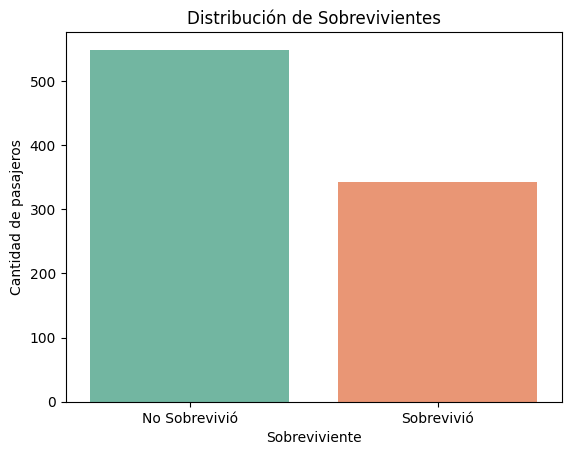

Survived
0    62.0
1    38.0
Name: proportion, dtype: float64

In [15]:
# Visualización de Survived

sobrevivientes = df['Survived'].value_counts(normalize=True)

sns.countplot(
    data=df,
    x='Survived',
    palette='Set2')

plt.title('Distribución de Sobrevivientes')
plt.xlabel('Sobreviviente')
plt.ylabel('Cantidad de pasajeros')
plt.xticks(ticks=[0, 1], labels=['No Sobrevivió', 'Sobrevivió'])
plt.show()

round(sobrevivientes, 2)*100



## Variables categóricas

In [16]:
# Variables categoricas sex embarked y Pclass validación

resumen_pclass = pd.Series({
    "tipo": df["Pclass"].dtype,
    "nulos": df["Pclass"].isna().sum(),
    "valores unicos": df["Pclass"].nunique(),
    "conteo valores unicos": df["Pclass"].value_counts()

})
resumen_pclass


tipo                                                                 int64
nulos                                                                    0
valores unicos                                                           3
conteo valores unicos    Pclass
3    491
1    216
2    184
Name: count,...
dtype: object

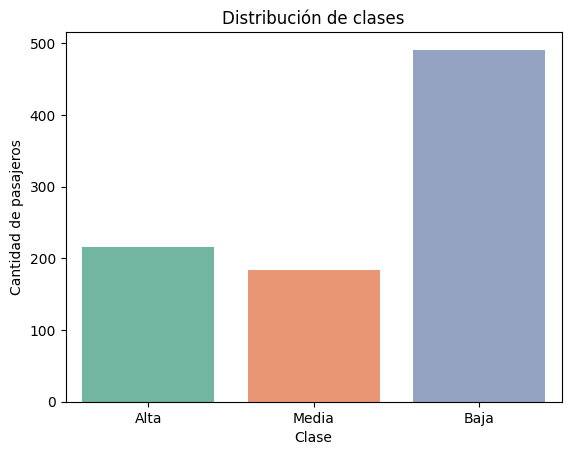

Pclass
3    55.0
1    24.0
2    21.0
Name: proportion, dtype: float64

In [17]:
# Visualización univariada de Pclass

sns.countplot(
    data=df,
    x="Pclass",
    palette="Set2")

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad de pasajeros")
plt.xticks(ticks=[0,1,2], labels=["Alta", "Media", "Baja"])
plt.show()

df["Pclass"].value_counts(normalize=True).round(2)*100

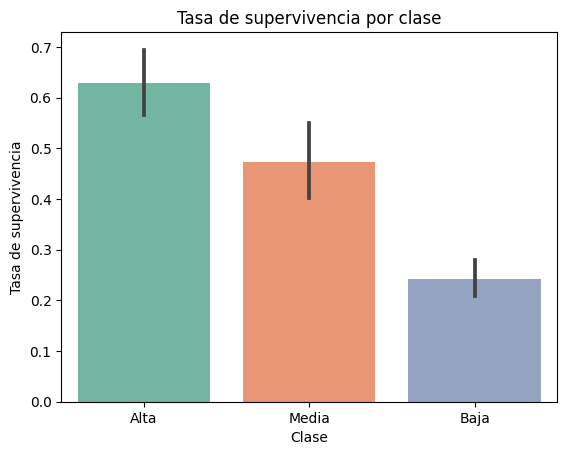

In [18]:
# Visualización bivariada de Pclass y Survived

sns.barplot(
    data=df,
    x="Pclass", 
    y="Survived", 
    palette="Set2")

plt.title("Tasa de supervivencia por clase")
plt.xlabel("Clase") 
plt.ylabel("Tasa de supervivencia")
plt.xticks(ticks=[0,1,2], labels=["Alta", "Media", "Baja"])
plt.show()




In [19]:
# Relación entre Pclass y Survived con diff y crosstab

tasa_ps=df.groupby("Pclass")["Survived"].mean().round(2) * 100
diff = tasa_ps.max() - tasa_ps.min()
print(f"Diferencia en tasa de supervivencia entre clases: {diff}%")

crosstab_ps = pd.crosstab(df["Pclass"], df["Survived"], normalize="index") * 100
print(f"Tabla de contingencia (normalizada por fila):")
print(crosstab_ps.round(2))

Diferencia en tasa de supervivencia entre clases: 39.0%
Tabla de contingencia (normalizada por fila):
Survived      0      1
Pclass                
1         37.04  62.96
2         52.72  47.28
3         75.76  24.24


In [20]:
# Validación de sex

resumen_sex= pd.Series({
    "tipo": df["Sex"].dtype,
    "nulos  ": df["Sex"].isna().sum(),
    "valores unicos": df["Sex"].nunique(),
    "conteo valores unicos": df["Sex"].value_counts()
})

resumen_sex

tipo                                                                object
nulos                                                                    0
valores unicos                                                           2
conteo valores unicos    Sex
male      577
female    314
Name: count, d...
dtype: object

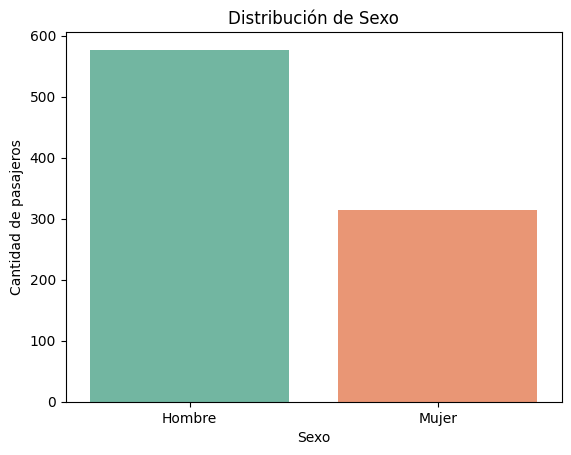

Sex
male      65.0
female    35.0
Name: proportion, dtype: float64

In [21]:
# Visualización univariada de Sex

sns.countplot(
    data=df, 
    x="Sex",
    palette="Set2")

plt.title('Distribución de Sexo')
plt.xlabel('Sexo')  
plt.ylabel('Cantidad de pasajeros')
plt.xticks(ticks=[0,1], labels=['Hombre', 'Mujer'])  
plt.show()

df["Sex"].value_counts(normalize=True).round(2)*100

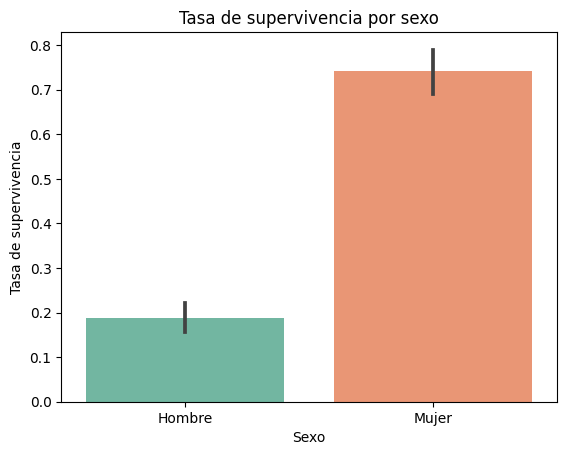

In [22]:
#Visualización bivariada de Sex y Survived

sns.barplot(
    data=df,
    x="Sex",
    y="Survived",
    palette="Set2")

plt.title('Tasa de supervivencia por sexo')
plt.xlabel('Sexo')  
plt.ylabel('Tasa de supervivencia')
plt.xticks(ticks=[0,1], labels=['Hombre', 'Mujer'])  
plt.show()



In [23]:
# Relación entre Sex y Survived con diff y crosstab

tasa_ss=df.groupby("Sex")["Survived"].mean().round(2)*100
diff = tasa_ss.max() - tasa_ss.min()
print(f"Diferencia en tasa de supervivencia entre hombres y mujeres: {diff}%")

crosstab_ss = pd.crosstab(df["Sex"], df["Survived"], normalize="index") * 100
print(f"Tabla de contingencia (normalizada por fila):")
print(crosstab_ss.round(2))

Diferencia en tasa de supervivencia entre hombres y mujeres: 55.0%
Tabla de contingencia (normalizada por fila):
Survived      0      1
Sex                   
female    25.80  74.20
male      81.11  18.89


In [24]:
# Validación de Embarked

resumen_embarked = pd.Series({
    "tipo": df["Embarked"].dtype,
    "nulos": df["Embarked"].isna().sum(),
    "valores unicos": df["Embarked"].nunique(),
    "conteo valores unicos": df["Embarked"].value_counts()
})

resumen_embarked

tipo                                                                object
nulos                                                                    2
valores unicos                                                           3
conteo valores unicos    Embarked
S    644
C    168
Q     77
Name: coun...
dtype: object

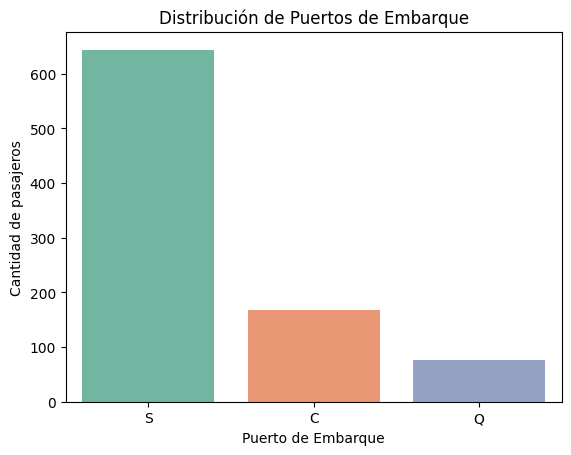

Embarked
S    72.0
C    19.0
Q     9.0
Name: proportion, dtype: float64

In [25]:
# Visualización univariada de Embarked

sns.countplot(
    data=df,
    x="Embarked",
    palette="Set2")

plt.title('Distribución de Puertos de Embarque')
plt.xlabel('Puerto de Embarque')
plt.ylabel('Cantidad de pasajeros')
plt.show()

df["Embarked"].value_counts(normalize=True).round(2)*100

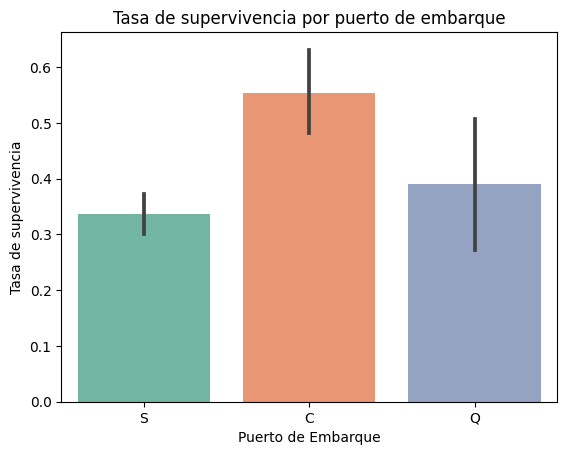

In [26]:
# Visualización bivariada de Embarked y Survived

sns.barplot(
    data=df,
    x="Embarked",
    y="Survived",
    palette="Set2")

plt.title('Tasa de supervivencia por puerto de embarque')
plt.xlabel('Puerto de Embarque')
plt.ylabel('Tasa de supervivencia')
plt.show()


In [27]:
# Relación entre Embarked y Survived con diff y crosstab

tasa_es=df.groupby("Embarked")["Survived"].mean().round(2)*100
diff_embarked = tasa_es.max() - tasa_es.min()
print(f"Diferencia en tasa de supervivencia entre puertos de embarque: {diff_embarked}%")

crosstab_es = pd.crosstab(df["Embarked"], df["Survived"], normalize="index") * 100
print(f"Tabla de contingencia (normalizada por fila):")
print(crosstab_es.round(2))

Diferencia en tasa de supervivencia entre puertos de embarque: 21.000000000000007%
Tabla de contingencia (normalizada por fila):
Survived      0      1
Embarked              
C         44.64  55.36
Q         61.04  38.96
S         66.30  33.70


## Variables numéricas

### Discretas

In [30]:
def resumen_numericas_discretas (df, col):
    data = df[col]
    
    resumen = {
        "variable": col,
        "dtype": data.dtype,
        "n": data.shape[0],
        "nulos": data.isna().sum(),
        "% nulos": round(data.isna().mean() * 100, 2),
        "valores unicos": data.nunique(),
        "conteo valores unicos": data.value_counts().to_dict(),
        "min": data.min(),
        "max": data.max(),
        "moda": data.mode().iloc[0]
    }
    
    return pd.DataFrame([resumen])

In [31]:
# SibSp validación Hermanos y cónyuges a bordo

resumen_numericas_discretas(df, 'SibSp')

,variable,dtype,n,nulos,% nulos,valores unicos,conteo valores unicos,min,max,moda
0,SibSp,int64,891,0,0.0,7,"{0: 608, 1: 209, 2: 28, 4: 18, 3: 16, 8: 7, 5: 5}",0,8,0


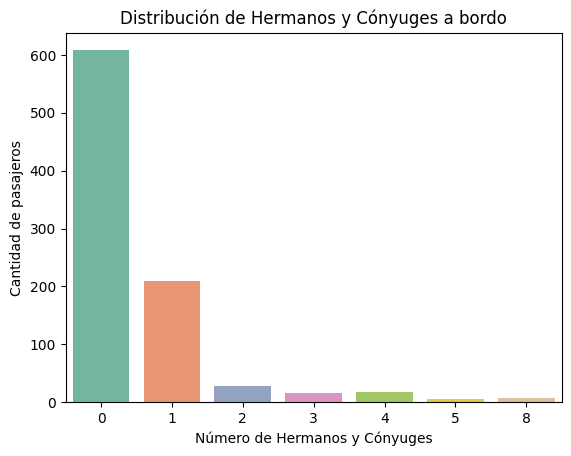

In [32]:
# Visualización de sibsp

sns.countplot(
    data=df,
    x='SibSp',
    palette='Set2')
plt.title('Distribución de Hermanos y Cónyuges a bordo')
plt.xlabel('Número de Hermanos y Cónyuges')
plt.ylabel('Cantidad de pasajeros')
plt.show()

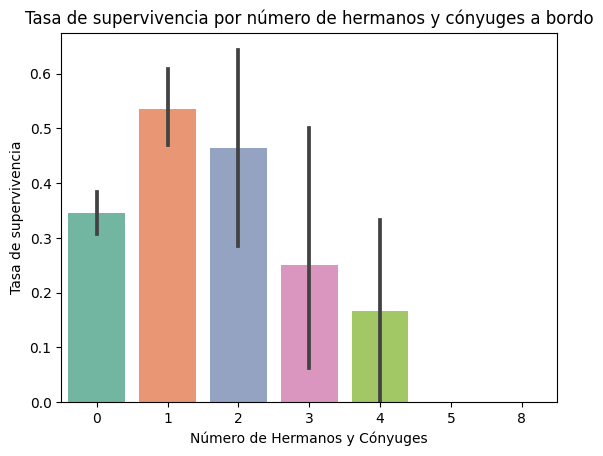

In [33]:
#Visualización bivariada de SibSp y Survived
sns.barplot(
    data=df,
    x='SibSp',
    y='Survived',
    palette='Set2')
plt.title('Tasa de supervivencia por número de hermanos y cónyuges a bordo')
plt.xlabel('Número de Hermanos y Cónyuges')
plt.ylabel('Tasa de supervivencia')
plt.show()

In [34]:
# Tasa de supervivencia por número de hermanos y cónyuges a bordo

tasa_sibsp = df.groupby("SibSp")["Survived"].mean().round(2)*100
diff_sibsp = tasa_sibsp.max() - tasa_sibsp.min()
print(f"Diferencia en tasa de supervivencia entre número de hermanos y cónyuges: {diff_sibsp}%")

crosstab_sibsp = pd.crosstab(df["SibSp"], df["Survived"], normalize="index") * 100
print(f"Tabla de contingencia (normalizada por fila):")
print(crosstab_sibsp.round(2))

Diferencia en tasa de supervivencia entre número de hermanos y cónyuges: 54.0%
Tabla de contingencia (normalizada por fila):
Survived       0      1
SibSp                  
0          65.46  34.54
1          46.41  53.59
2          53.57  46.43
3          75.00  25.00
4          83.33  16.67
5         100.00   0.00
8         100.00   0.00


In [35]:
# Validación de Parch

resumen_numericas_discretas(df, 'Parch')

,variable,dtype,n,nulos,% nulos,valores unicos,conteo valores unicos,min,max,moda
0,Parch,int64,891,0,0.0,7,"{0: 678, 1: 118, 2: 80, 5: 5, 3: 5, 4: 4, 6: 1}",0,6,0


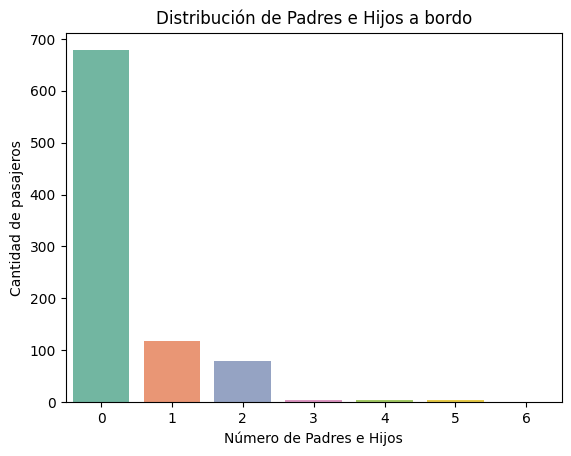

In [36]:
# Visualización de Parch

sns.countplot(
    data=df,
    x='Parch',
    palette='Set2')
plt.title('Distribución de Padres e Hijos a bordo')
plt.xlabel('Número de Padres e Hijos')
plt.ylabel('Cantidad de pasajeros')
plt.show()

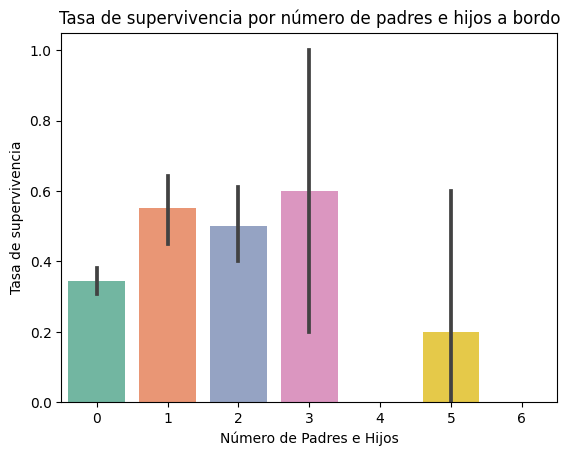

In [37]:
# Visualización de Parch y Survived

sns.barplot(
    data=df,
    x='Parch',
    y='Survived',
    palette='Set2')
plt.title('Tasa de supervivencia por número de padres e hijos a bordo')
plt.xlabel('Número de Padres e Hijos')  
plt.ylabel('Tasa de supervivencia')
plt.show()

In [55]:
# crosstab de Parch y Survived
tasa_ps=df.groupby("Parch")["Survived"].mean().round(2)*100
diff_ps = tasa_ps.max() - tasa_ps.min() 
print(f"Diferencia en tasa de supervivencia entre número de padres e hijos: {diff_ps}%")

crosstab_ps = pd.crosstab(df["Parch"], df["Survived"], normalize="index") * 100
print(f"Tabla de contingencia (normalizada por fila):")
print(crosstab_ps)

Diferencia en tasa de supervivencia entre número de padres e hijos: 60.0%
Tabla de contingencia (normalizada por fila):
Survived           0          1
Parch                          
0          65.634218  34.365782
1          44.915254  55.084746
2          50.000000  50.000000
3          40.000000  60.000000
4         100.000000   0.000000
5          80.000000  20.000000
6         100.000000   0.000000


### Continuas

In [38]:
# Validación Variables numéricas Age, SibSp, Parch y Fare
def resumen_numericas (df, col):
    data = df[col]
    
    resumen = {
        "variable": col,
        "dtype": data.dtype,
        "n": data.shape[0],
        "nulos": data.isna().sum(),
        "pct_nulos": round(data.isna().mean() * 100, 2),
        "min": data.min(),
        "max": data.max(),
        "media": data.mean(),
        "mediana": data.median(),
        "std": data.std(),
        "sesgo": (data.mean() - data.median())/data.std(),
        "cv": data.std()/data.mean(),
        "var": data.var(),
        "skewness": data.skew(),
        "kurtosis": data.kurt(),
        "quantiles": data.quantile([0.25, 0.5, 0.75]).to_dict(),
        "iqr": data.quantile(0.75) - data.quantile(0.25),
        "iqr relativo": (data.quantile(0.75) - data.quantile(0.25))/data.median(),
        "outliers LS": data.quantile(0.75) + 1.5 * (data.quantile(0.75) - data.quantile(0.25)),
        "outliers LI": data.quantile(0.25) - 1.5 * (data.quantile(0.75) - data.quantile(0.25))
    }
    
    return pd.DataFrame([resumen])


In [39]:
# Age validación

resumen_numericas(df, 'Age')

,variable,dtype,n,nulos,pct_nulos,min,max,media,mediana,std,sesgo,cv,var,skewness,kurtosis,quantiles,iqr,iqr relativo,outliers LS,outliers LI
0,Age,float64,891,177,19.87,0.42,80.0,29.699118,28.0,14.526497,0.116967,0.489122,211.019125,0.389108,0.178274,"{0.25: 20.125, 0.5: 28.0, 0.75: 38.0}",17.875,0.638393,64.8125,-6.6875


C:\Users\ERIKA PINCHAO\AppData\Local\Temp\ipykernel_10116\2951429254.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Age'], kde=True, bins=30, palette="Set2")


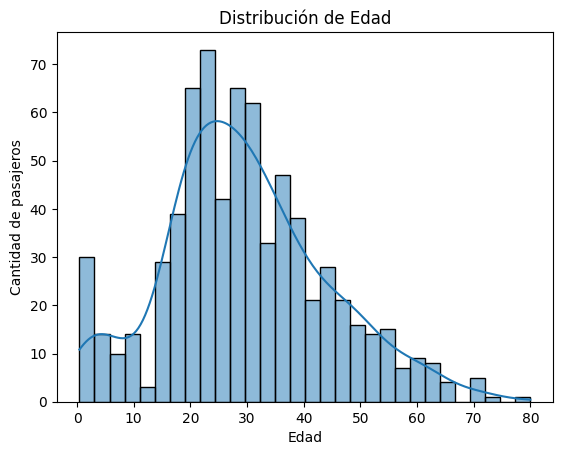

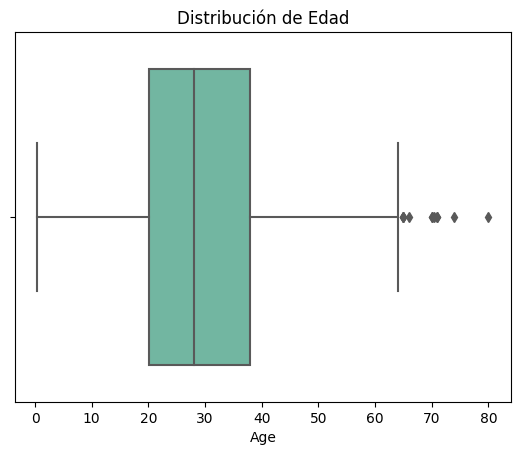

In [40]:
sns.histplot(df['Age'], kde=True, bins=30, palette="Set2")
plt.title('Distribución de Edad')   
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.show()

sns.boxplot(x=df['Age'], palette="Set2")
plt.title('Distribución de Edad') 
plt.show()

In [41]:
# Distribución entre Age y Survived 

df.groupby("Survived")["Age"].agg(["mean", "median", "count"])

,mean,median,count
Survived,,,
0,30.626179,28.0,424
1,28.343690,28.0,290


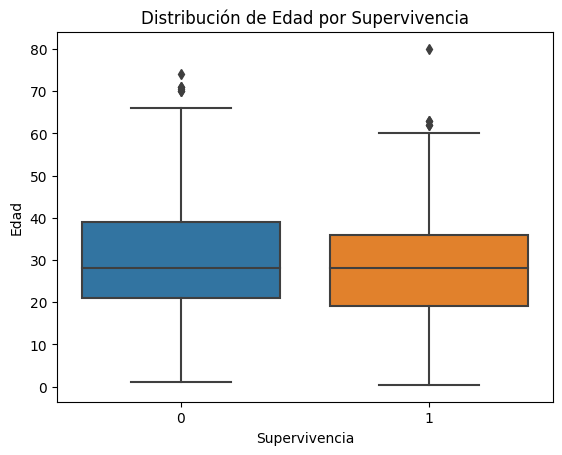

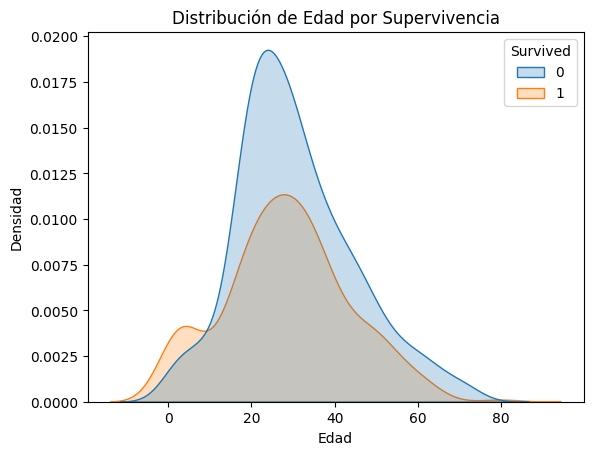

In [42]:
# Visualización de distribución de Age por Survived

sns.boxplot(x="Survived", y="Age", data=df)
plt.title('Distribución de Edad por Supervivencia')
plt.xlabel('Supervivencia')
plt.ylabel('Edad')
plt.show()

sns.kdeplot(data=df, x="Age", hue="Survived", fill=True)
plt.title('Distribución de Edad por Supervivencia')
plt.xlabel('Edad')
plt.ylabel('Densidad')
plt.show()

In [43]:
df["Age_bin"] = pd.cut(df["Age"], bins=5)

tasa_as = pd.crosstab(df["Age_bin"], df["Survived"], normalize="index")

tamaño = df.groupby("Age_bin")["Survived"].size()

tasa_as.round(2)*100, tamaño

(Survived             0     1
 Age_bin                     
 (0.34, 16.336]    45.0  55.0
 (16.336, 32.252]  63.0  37.0
 (32.252, 48.168]  60.0  40.0
 (48.168, 64.084]  57.0  43.0
 (64.084, 80.0]    91.0   9.0,
 Age_bin
 (0.34, 16.336]      100
 (16.336, 32.252]    346
 (32.252, 48.168]    188
 (48.168, 64.084]     69
 (64.084, 80.0]       11
 Name: Survived, dtype: int64)

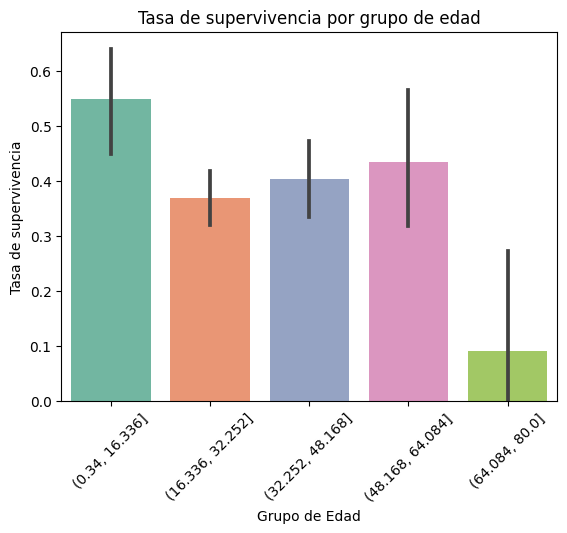

In [44]:

sns.barplot(
    data=df,
    x="Age_bin",
    y="Survived",
    palette="Set2")
plt.title('Tasa de supervivencia por grupo de edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Tasa de supervivencia')
plt.xticks(rotation=45)
plt.show()

In [45]:
df["Age_null"] = df["Age"].isnull()

pd.crosstab(df["Age_null"], df["Survived"], normalize="index")

Survived,0,1
Age_null,,
False,0.593838,0.406162
True,0.706215,0.293785


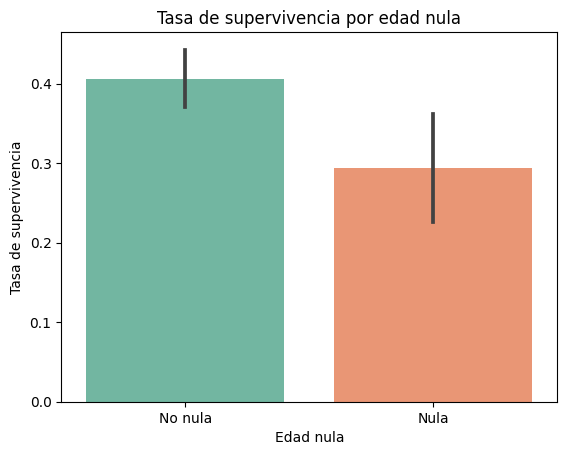

In [46]:
sns.barplot(
    data=df,
    x="Age_null",
    y="Survived",
    palette="Set2")
plt.title('Tasa de supervivencia por edad nula')
plt.xlabel('Edad nula')
plt.ylabel('Tasa de supervivencia')
plt.xticks(ticks=[0,1], labels=['No nula', 'Nula'])
plt.show()

In [47]:
# Validación de Fare

resumen_numericas(df, 'Fare')

,variable,dtype,n,nulos,pct_nulos,min,max,media,mediana,std,sesgo,cv,var,skewness,kurtosis,quantiles,iqr,iqr relativo,outliers LS,outliers LI
0,Fare,float64,891,0,0.0,0.0,512.3292,32.204208,14.4542,49.693429,0.35719,1.543073,2469.436846,4.787317,33.398141,"{0.25: 7.9104, 0.5: 14.4542, 0.75: 31.0}",23.0896,1.597432,65.6344,-26.724


C:\Users\ERIKA PINCHAO\AppData\Local\Temp\ipykernel_10116\2809895520.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Fare'], kde=True, bins=30, palette="Set2")


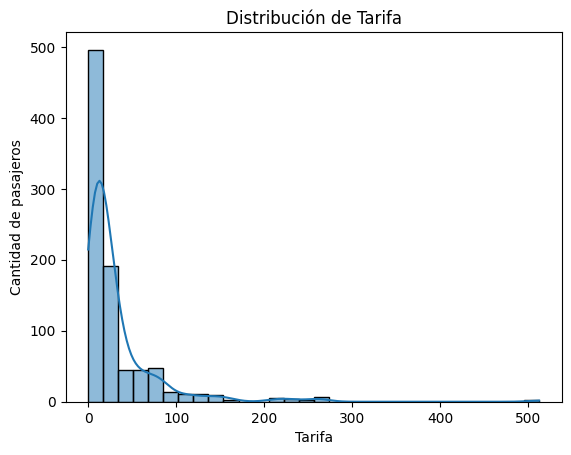

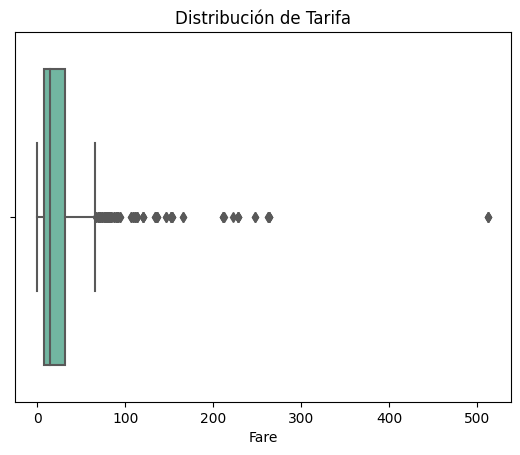

In [48]:
# Visualización de Fare

sns.histplot(df['Fare'], kde=True, bins=30, palette="Set2")
plt.title('Distribución de Tarifa') 
plt.xlabel('Tarifa')
plt.ylabel('Cantidad de pasajeros') 
plt.show()

sns.boxplot(x=df['Fare'], palette="Set2")
plt.title('Distribución de Tarifa')
plt.show()

In [49]:
# Distribución entre Fare y Survived

df.groupby("Survived")["Fare"].agg(["mean", "median", "count"])

,mean,median,count
Survived,,,
0,22.117887,10.5,549
1,48.395408,26.0,342


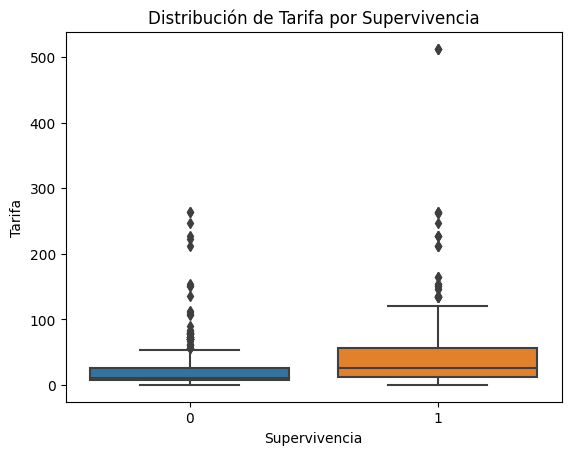

In [50]:
# Visualización de Fare por Survived

sns.boxplot(x="Survived", y="Fare", data=df)
plt.title('Distribución de Tarifa por Supervivencia')   
plt.xlabel('Supervivencia')
plt.ylabel('Tarifa')
plt.show()

In [51]:
# Relacion entre Fare y Survived con diff y crosstab

df["Fare_bin"] = pd.qcut(df["Fare"], q=4)

tasa_fs=pd.crosstab(df["Fare_bin"], df["Survived"], normalize="index")

tamaño_fare = df.groupby("Fare_bin")["Survived"].size()

tasa_fs.round(2)*100, tamaño_fare

(Survived            0     1
 Fare_bin                   
 (-0.001, 7.91]   80.0  20.0
 (7.91, 14.454]   70.0  30.0
 (14.454, 31.0]   55.0  45.0
 (31.0, 512.329]  42.0  58.0,
 Fare_bin
 (-0.001, 7.91]     223
 (7.91, 14.454]     224
 (14.454, 31.0]     222
 (31.0, 512.329]    222
 Name: Survived, dtype: int64)

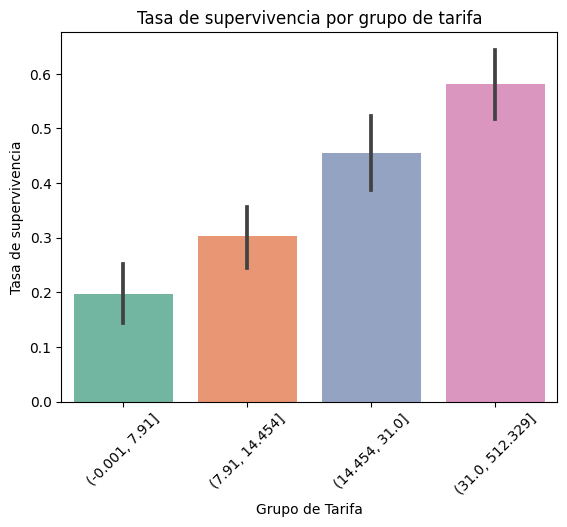

In [52]:
# Visualización de Fare por Survived

sns.barplot(
    data=df,
    x="Fare_bin",
    y="Survived",
    palette="Set2") 
plt.title('Tasa de supervivencia por grupo de tarifa')
plt.xlabel('Grupo de Tarifa')
plt.ylabel('Tasa de supervivencia')
plt.xticks(rotation=45)
plt.show()

## Interacciones

#### Catégorica x Catégorica

In [58]:
# Crosstab Pclass, Sex y Survived
crosstab_pss = pd.crosstab([df["Pclass"], df["Sex"]], df["Survived"], normalize="index") * 100
diff_pss = crosstab_pss[1].max() - crosstab_pss[1].min()
print(f"Diferencia en tasa de supervivencia entre clases y sexos: {diff_pss}%")
print(f"Tabla de contingencia (normalizada por fila):")
print(crosstab_pss) 

Diferencia en tasa de supervivencia entre clases y sexos: 83.26384205040162%
Tabla de contingencia (normalizada por fila):
Survived               0          1
Pclass Sex                         
1      female   3.191489  96.808511
       male    63.114754  36.885246
2      female   7.894737  92.105263
       male    84.259259  15.740741
3      female  50.000000  50.000000
       male    86.455331  13.544669


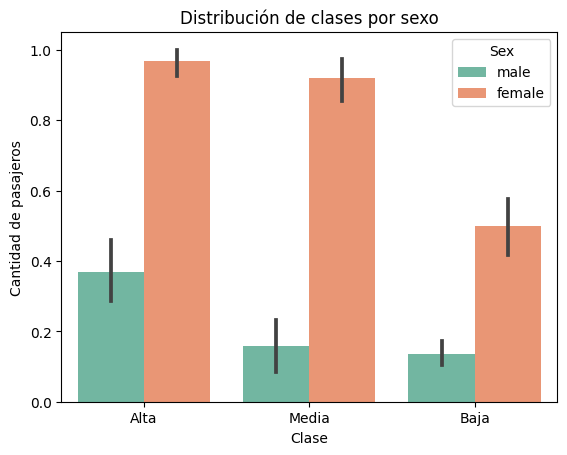

In [53]:
# Visualización multivariada de Pclass, Sex y Survived

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex",
    palette="Set2")

plt.title('Distribución de clases por sexo')
plt.xlabel('Clase') 
plt.ylabel('Cantidad de pasajeros')
plt.xticks(ticks=[0,1,2], labels=["Alta", "Media", "Baja"])
plt.show()



In [64]:
#Crosstab de Pclass, Embarked y Survived

crosstab_pse = pd.crosstab([df["Pclass"], df["Embarked"]], df["Survived"], normalize="index") * 100
print(f"Tabla de contingencia (normalizada por fila):", crosstab_pse.round(2))
print(df.groupby(['Embarked', 'Pclass'])['Survived'].size())

Tabla de contingencia (normalizada por fila): Survived             0      1
Pclass Embarked              
1      C         30.59  69.41
       Q         50.00  50.00
       S         41.73  58.27
2      C         47.06  52.94
       Q         33.33  66.67
       S         53.66  46.34
3      C         62.12  37.88
       Q         62.50  37.50
       S         81.02  18.98
Embarked  Pclass
C         1          85
          2          17
          3          66
Q         1           2
          2           3
          3          72
S         1         127
          2         164
          3         353
Name: Survived, dtype: int64


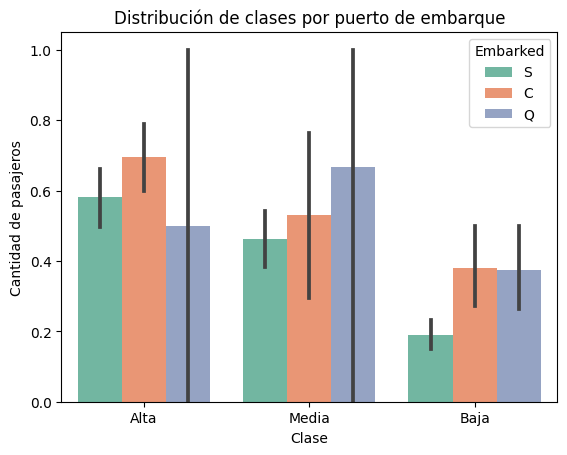

In [62]:
# Visualización multivariada de Pclass, Embarked y Survived

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Embarked",
    palette="Set2")
plt.title('Distribución de clases por puerto de embarque')
plt.xlabel('Clase')
plt.ylabel('Cantidad de pasajeros')
plt.xticks(ticks=[0,1,2], labels=["Alta", "Media", "Baja"])
plt.show()

#### Numérica x Numérica